In [ ]:
"""# 🏦 Credit Risk Prediction System

# 01 - Data Understanding

---

## Project Objective

The goal of this project is to develop an AI-powered Credit Risk Prediction System that predicts whether a loan applicant is likely to be a low-risk or high-risk customer based on historical credit information.

This notebook focuses on understanding the dataset before performing preprocessing, feature engineering, and machine learning.

---

## Objectives

- Load the dataset
- Understand the dataset structure
- Examine data types
- Identify missing values
- Detect duplicate records
- Generate descriptive statistics
- Understand the target variable
- Perform an initial data quality assessment"""

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

DATA_PATH = "../data/raw/german_credit_data.csv"

df = pd.read_csv(DATA_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

Dataset Loaded Successfully


In [3]:
# ==========================================================
# Display First Five Records
# ==========================================================

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# ==========================================================
# Display First Five Records
# ==========================================================

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
# ==========================================================
# Display Last Five Records
# ==========================================================

df.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,999,27,male,2,own,moderate,moderate,4576,45,car,good


In [6]:
# ==========================================================
# Column Names
# ==========================================================

print(df.columns.tolist())

['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


In [7]:
# ==========================================================
# Data Types
# ==========================================================

df.dtypes

Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

In [8]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [9]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

missing_values = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": round(
        (df.isnull().sum() / len(df)) * 100,
        2
    )

})

missing_values = missing_values.sort_values(

    by="Missing Values",

    ascending=False

)

missing_values

,Missing Values,Percentage
Checking account,394,39.4
Saving accounts,183,18.3
Unnamed: 0,0,0.0
Sex,0,0.0
Age,0,0.0
Housing,0,0.0
Job,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


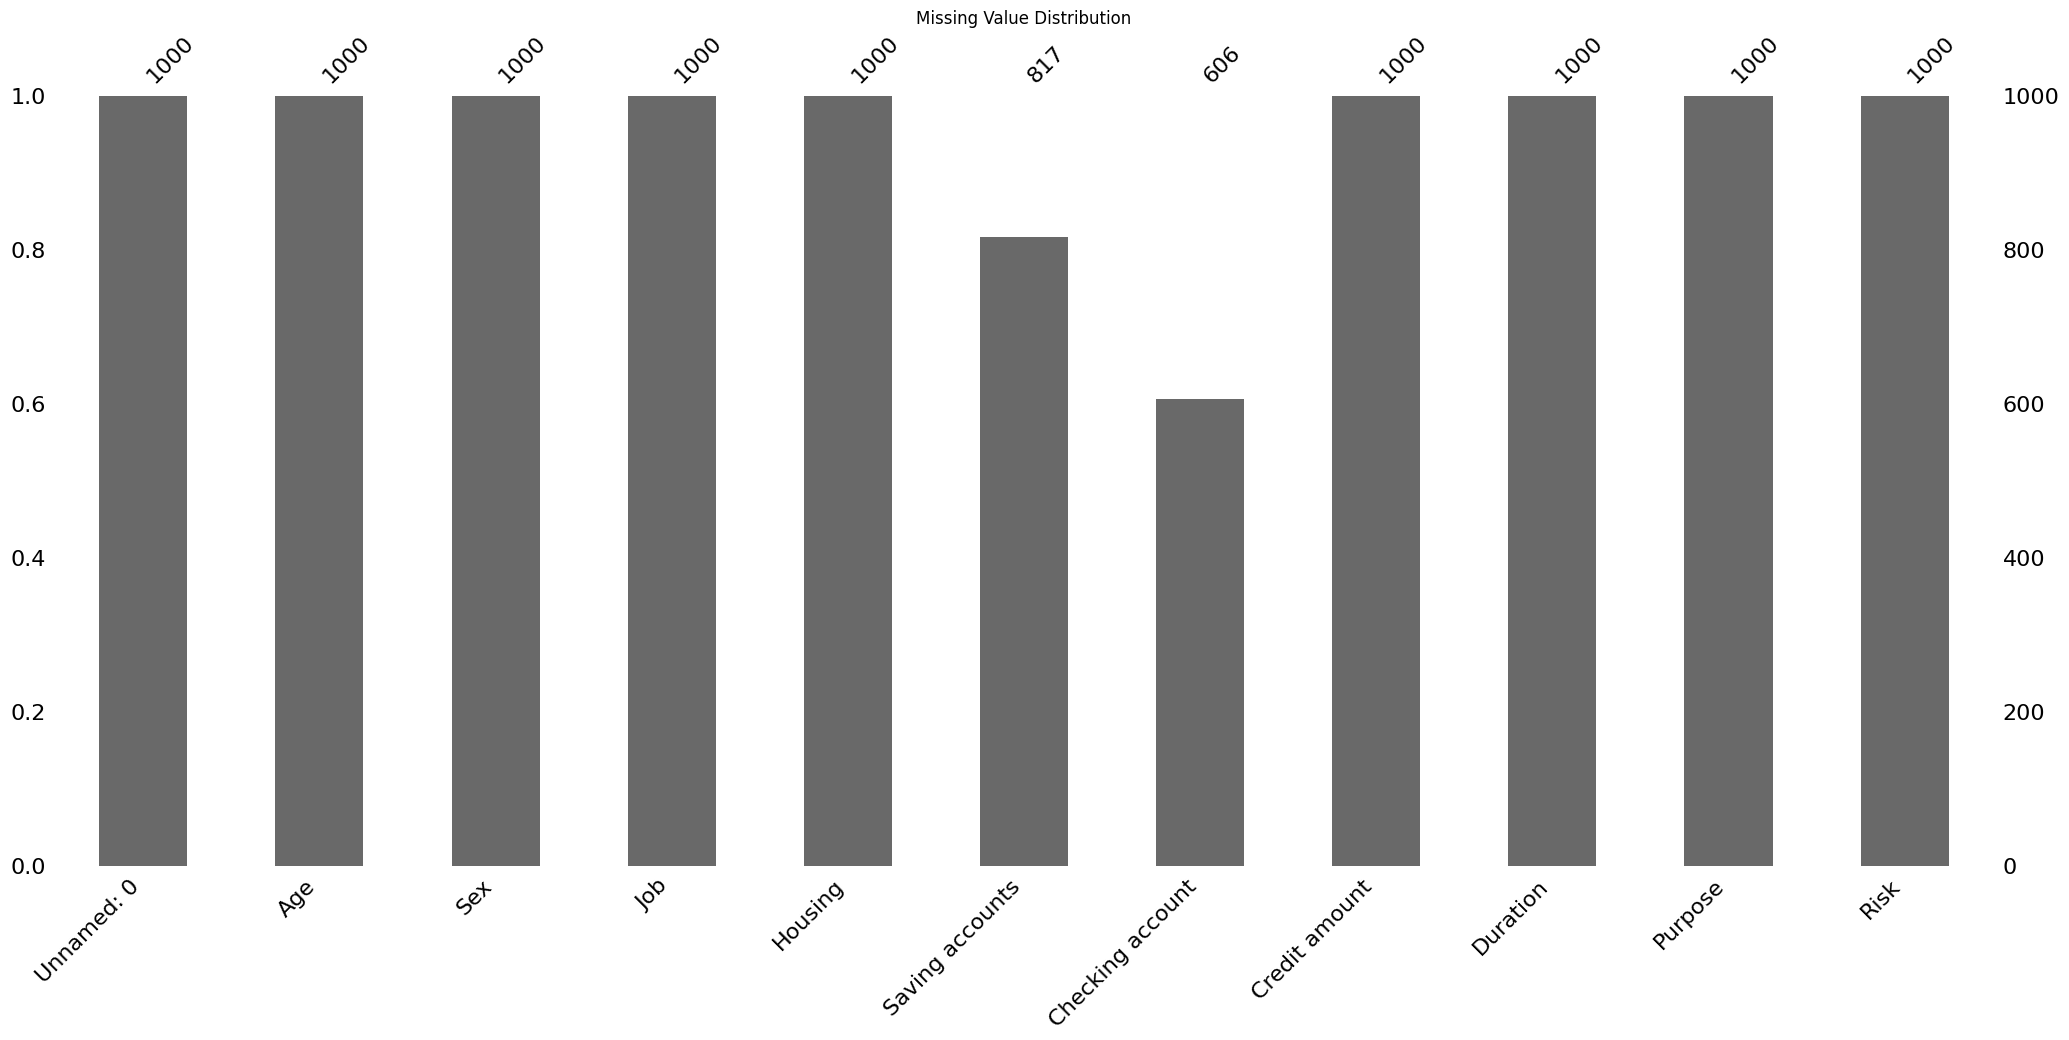

In [10]:
# ==========================================================
# Missing Value Visualization
# ==========================================================

plt.figure(figsize=(12,5))

msno.bar(df)

plt.title("Missing Value Distribution")

plt.show()

In [12]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("="*50)

print(f"Duplicate Records : {duplicates}")

print("="*50)

Duplicate Records : 0


In [13]:
# ==========================================================
# Unique Values
# ==========================================================

unique_values = pd.DataFrame({

    "Column": df.columns,

    "Unique Values": df.nunique().values

})

unique_values

,Column,Unique Values
0,Unnamed: 0,1000
1,Age,53
2,Sex,2
3,Job,4
4,Housing,3
5,Saving accounts,4
6,Checking account,3
7,Credit amount,921
8,Duration,33
9,Purpose,8


In [14]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,499.500,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,35.546,11.375469,19.0,27.00,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.00,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.50,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.00,18.0,24.00,72.0


In [15]:
# ==========================================================
# Categorical Summary
# ==========================================================

df.describe(include="object").T

,count,unique,top,freq
Sex,1000,2,male,690
Housing,1000,3,own,713
Saving accounts,817,4,little,603
Checking account,606,3,little,274
Purpose,1000,8,car,337
Risk,1000,2,good,700


In [16]:
# ==========================================================
# Numerical Columns
# ==========================================================

numerical_columns = df.select_dtypes(

    include=np.number

).columns.tolist()

print(numerical_columns)

['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration']


In [18]:
# ==========================================================
# Categorical Columns
# ==========================================================

categorical_columns = df.select_dtypes(

    include="object"

).columns.tolist()

print(categorical_columns)

['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']


In [19]:
# ==========================================================
# Memory Usage
# ==========================================================

memory = df.memory_usage(deep=True).sum()/1024**2

print(f"Dataset Memory Usage : {memory:.2f} MB")

Dataset Memory Usage : 0.38 MB


In [20]:
# ==========================================================
# Data Quality Report
# ==========================================================

report = pd.DataFrame({

    "Data Type": df.dtypes,

    "Missing": df.isnull().sum(),

    "Unique": df.nunique(),

    "Duplicate": df.duplicated().sum()

})

report

,Data Type,Missing,Unique,Duplicate
Unnamed: 0,int64,0,1000,0
Age,int64,0,53,0
Sex,object,0,2,0
Job,int64,0,4,0
Housing,object,0,3,0
Saving accounts,object,183,4,0
Checking account,object,394,3,0
Credit amount,int64,0,921,0
Duration,int64,0,33,0
Purpose,object,0,8,0


In [ ]:
"""# Initial Observations

## Dataset Summary

- Dataset loaded successfully.
- Missing values are present in Saving accounts and Checking account.
- No duplicate records found.
- Dataset contains both numerical and categorical features.
- Credit Amount and Duration have wide value ranges.
- Data cleaning is required before model training.

---

## Next Step

Proceed to:

02_Data_Cleaning.ipynb"""

In [21]:
# ==========================================================
# Create Output Folders
# ==========================================================

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

REPORT_DIR = OUTPUT_DIR / "reports"
TABLE_DIR = OUTPUT_DIR / "tables"
CHART_DIR = OUTPUT_DIR / "charts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders created successfully.")

Output folders created successfully.


In [22]:
# ==========================================================
# Save Dataset Summary
# ==========================================================

summary = pd.DataFrame({

    "Rows": [df.shape[0]],

    "Columns": [df.shape[1]],

    "Missing Values": [df.isnull().sum().sum()],

    "Duplicate Rows": [df.duplicated().sum()]

})

summary.to_csv(

    TABLE_DIR / "dataset_summary.csv",

    index=False

)

print("Dataset Summary Saved")

Dataset Summary Saved


In [23]:
# ==========================================================
# Save Missing Value Report
# ==========================================================

missing_values.to_csv(

    TABLE_DIR / "missing_value_report.csv"

)

print("Missing Value Report Saved")

Missing Value Report Saved


In [24]:
# ==========================================================
# Save Data Quality Report
# ==========================================================

report.to_csv(

    TABLE_DIR / "data_quality_report.csv"

)

print("Data Quality Report Saved")

Data Quality Report Saved


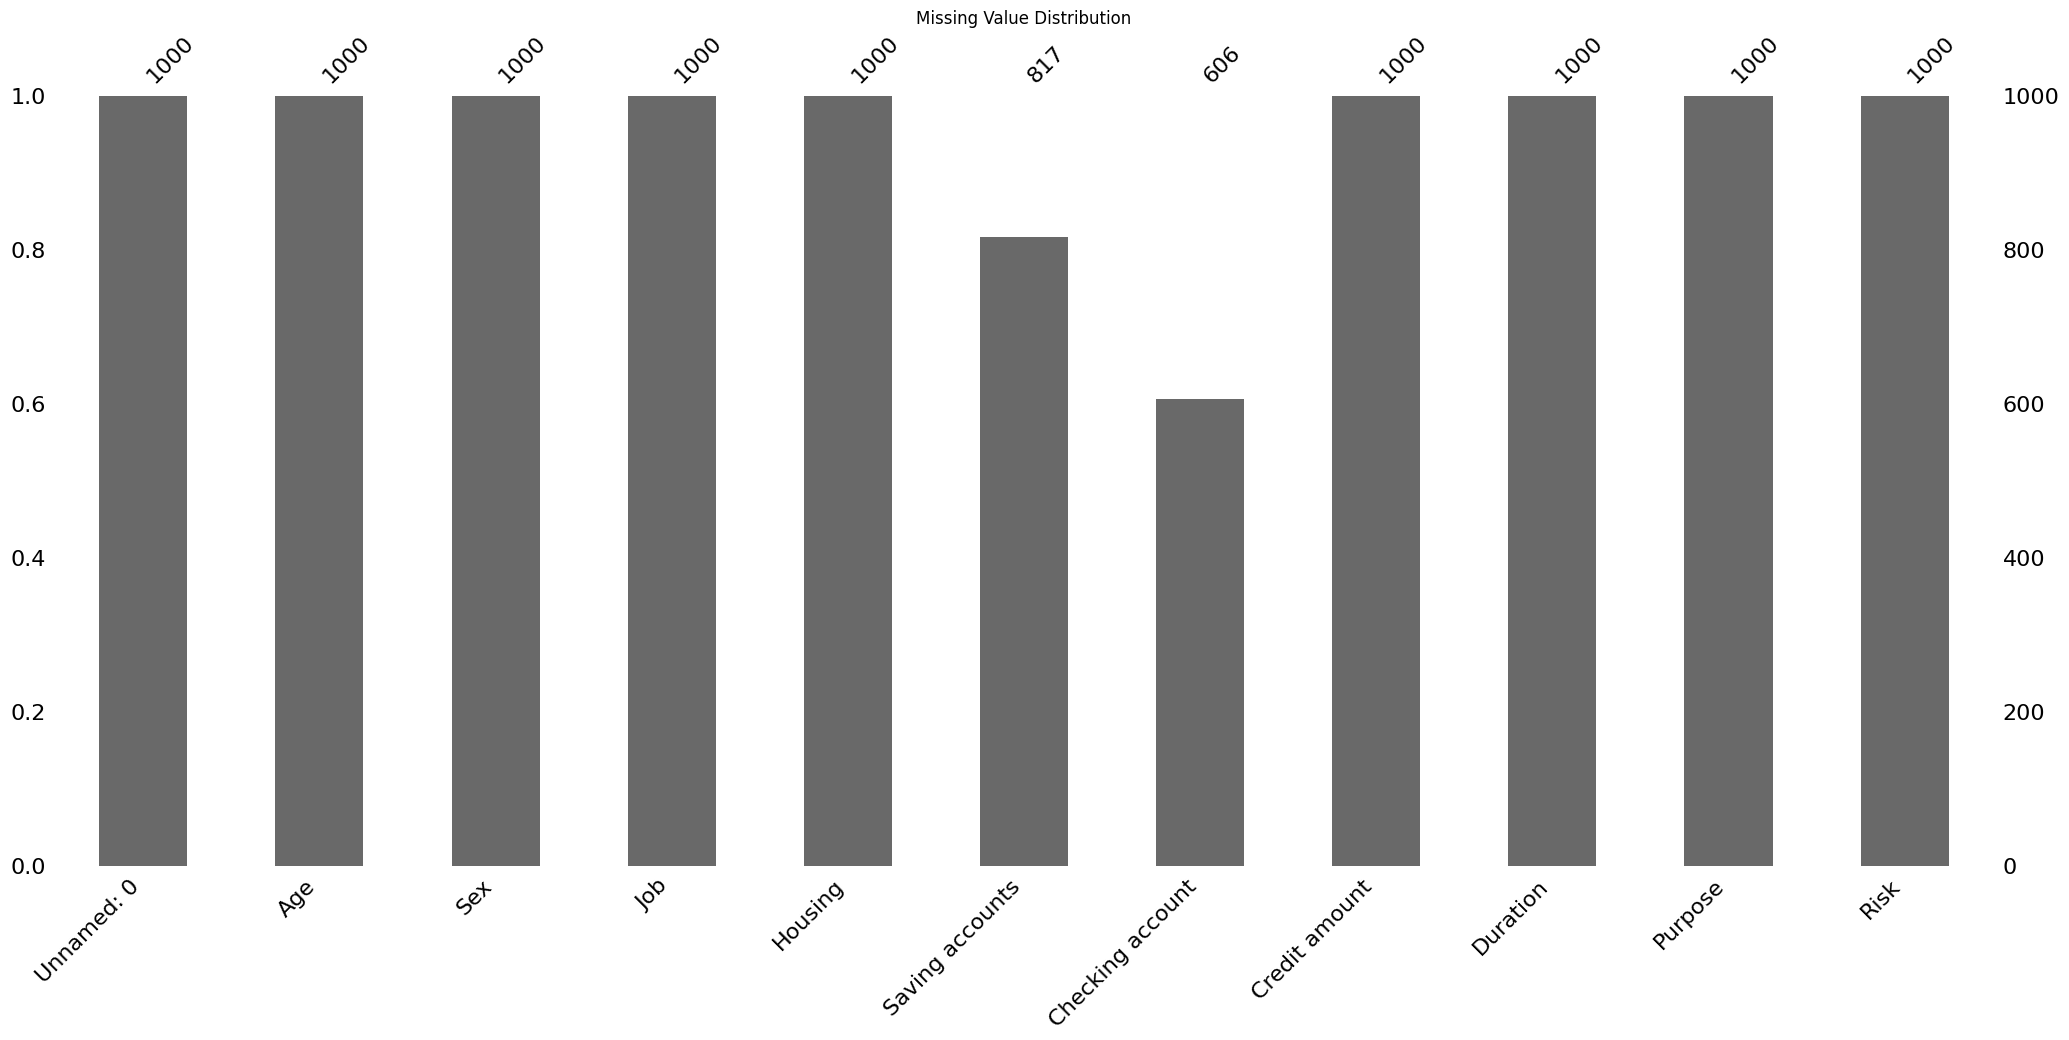

Chart Saved


In [25]:
# ==========================================================
# Save Missing Value Chart
# ==========================================================

plt.figure(figsize=(12,5))

msno.bar(df)

plt.title("Missing Value Distribution")

plt.savefig(

    CHART_DIR / "missing_value_chart.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("Chart Saved")